# Velocity at Depth Levels

The goal of this notebook is the following:

1) serve as an example of how to post-process CESM/MOM6 output;

2) create time averages of Eulerian velocity fields at depth levels;

In [1]:
%matplotlib inline
from mom6_tools.MOM6grid import MOM6grid
from mom6_tools.m6plot import xyplot
from mom6_tools.DiagsCase import DiagsCase
from mom6_tools import m6toolbox
import matplotlib.pyplot as plt
from ncar_jobqueue import NCARCluster
from dask.distributed import Client
import yaml, intake
import numpy as np
import xarray as xr
from IPython.display import display, Markdown, Latex
import warnings
warnings.filterwarnings("ignore")

/glade/work/gmarques/miniconda/envs/dev2/lib/python3.9/site-packages/dask_jobqueue/core.py:20: FutureWarning: tmpfile is deprecated and will be removed in a future release. Please use dask.utils.tmpfile instead.
  from distributed.utils import tmpfile


In [2]:
# Read in the yaml file
diag_config_yml_path = "diag_config.yml"
diag_config_yml = yaml.load(open(diag_config_yml_path,'r'), Loader=yaml.Loader)

# load avg dates
avg = diag_config_yml['Avg']

# Create the case instance
dcase = DiagsCase(diag_config_yml['Case'])
DOUT_S = dcase.get_value('DOUT_S')
if DOUT_S:
  OUTDIR = dcase.get_value('DOUT_S_ROOT')+'/ocn/hist/'
else:
  OUTDIR = dcase.get_value('RUNDIR')

print('Output directory is:', OUTDIR)
print('Casename is:', dcase.casename)

Output directory is: /glade/scratch/gmarques/archive/g.e23_b15.GJRAv4.TL319_t232_zstar_N65.baseline.001/ocn/hist/
Casename is: g.e23_b15.GJRAv4.TL319_t232_zstar_N65.baseline.001


In [3]:
# The following parameters must be set accordingly
######################################################

# create an empty class object
class args:
  pass# create an empty class object
class args:
  pass

args.start_date = avg['start_date']
args.end_date = avg['end_date']
args.casename = dcase.casename
args.monthly = dcase.casename+diag_config_yml['Fnames']['z']
args.static = dcase.casename+diag_config_yml['Fnames']['static']
args.savefigs = False
args.nw = 6 

args.start_date = avg['start_date']
args.end_date = avg['end_date']
args.casename = dcase.casename
args.monthly = dcase.casename+diag_config_yml['Fnames']['z']
args.static = dcase.casename+diag_config_yml['Fnames']['static']
args.savefigs = False
args.nw = 6 # requesting 6 workers

In [4]:
# load mom6 grid
grd = MOM6grid(OUTDIR+args.static)

MOM6 grid successfully loaded... 



In [5]:
parallel = False
if args.nw > 1:
  parallel = True
  cluster = NCARCluster()
  cluster.scale(args.nw)
  client = Client(cluster)

In [6]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/gmarques/high_memory/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/gmarques/high_memory/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.12.206.40:36361,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/gmarques/high_memory/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [7]:
# load history files

def preprocess(ds):
    ''' Return a dataset desired variables'''
    variables = ['uo', 'vo', 'time', 'time_bounds']
    return ds[variables]

ds = xr.open_mfdataset(OUTDIR+args.monthly, \
         parallel=True, data_vars='minimal', \
         coords='minimal', compat='override', preprocess=preprocess)

In [8]:
# Select data
%time ds_sel = ds.sel(time=slice(args.start_date, args.end_date))

CPU times: user 9.31 ms, sys: 1.03 ms, total: 10.3 ms
Wall time: 16.1 ms


In [9]:
# compute annual mean and then average in time
ds_ann = m6toolbox.weighted_temporal_mean_vars(ds_sel)
uo = np.ma.masked_invalid(ds_ann.uo.mean('time').values)
vo = np.ma.masked_invalid(ds_ann.vo.mean('time').values)

### Zonal velocity

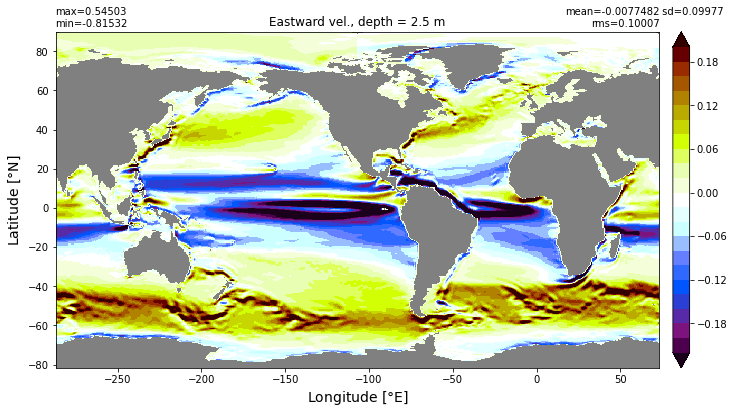

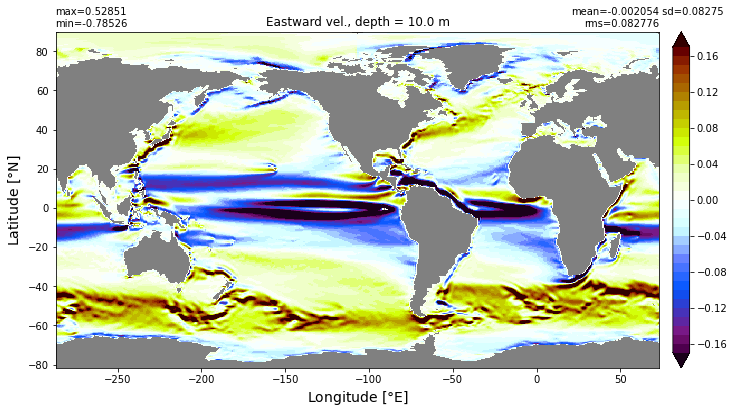

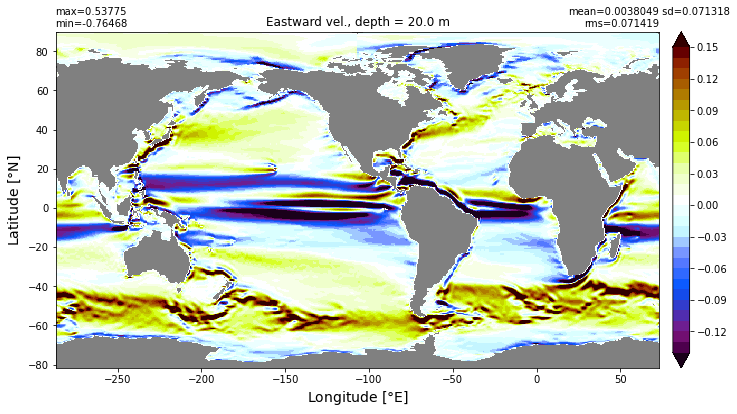

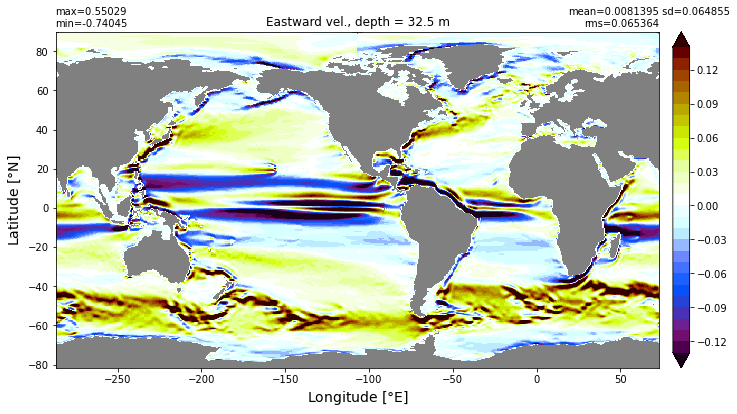

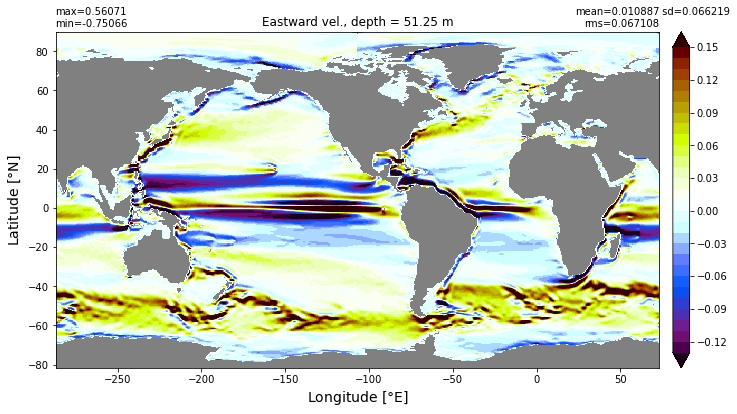

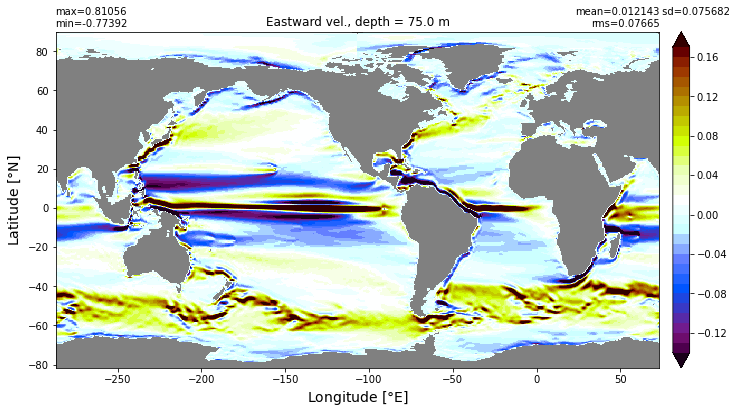

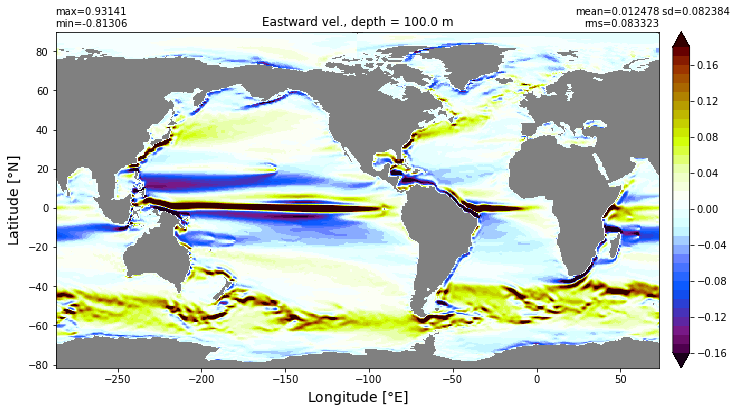

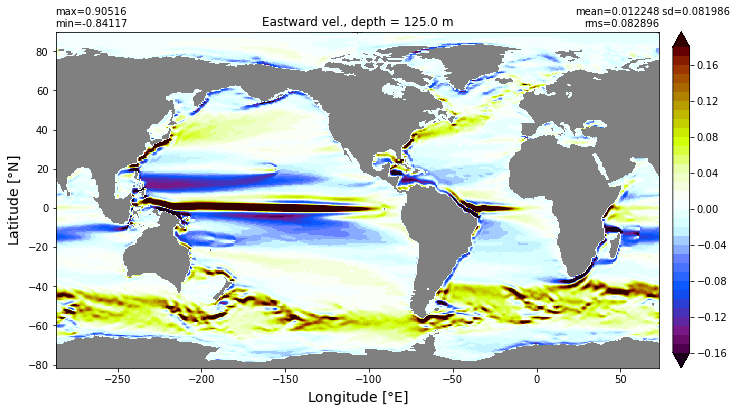

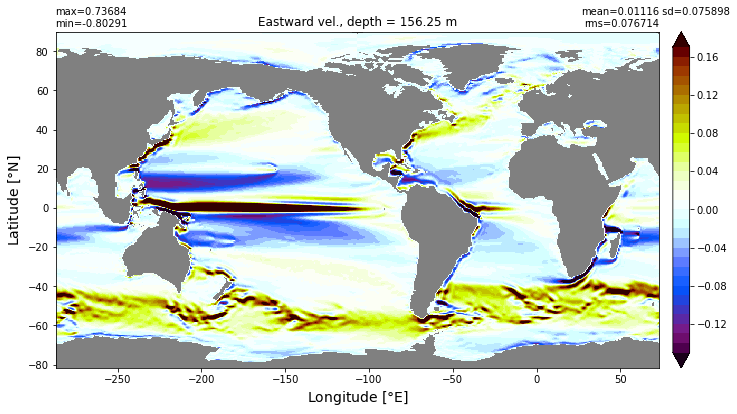

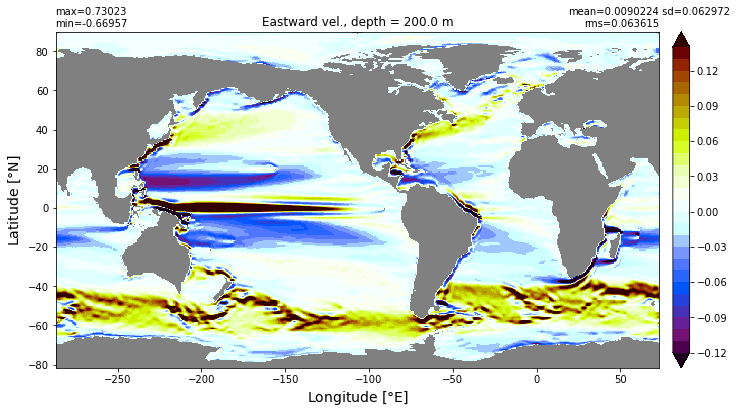

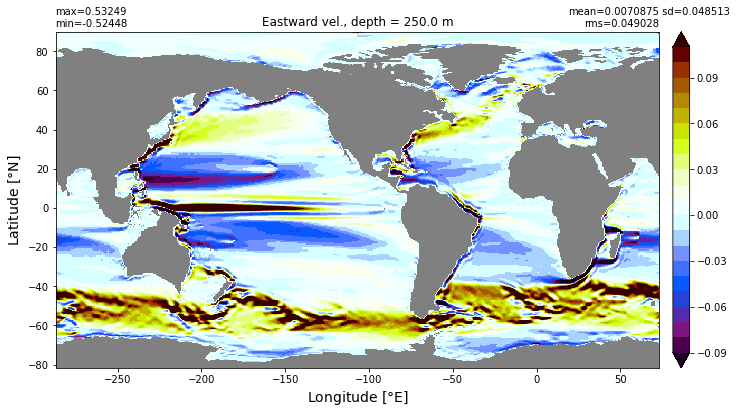

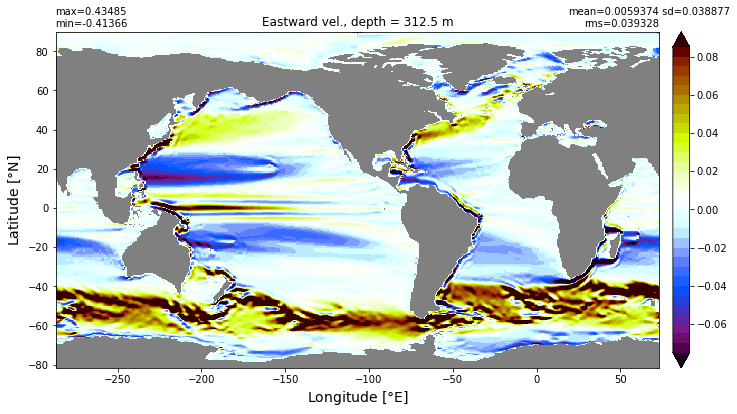

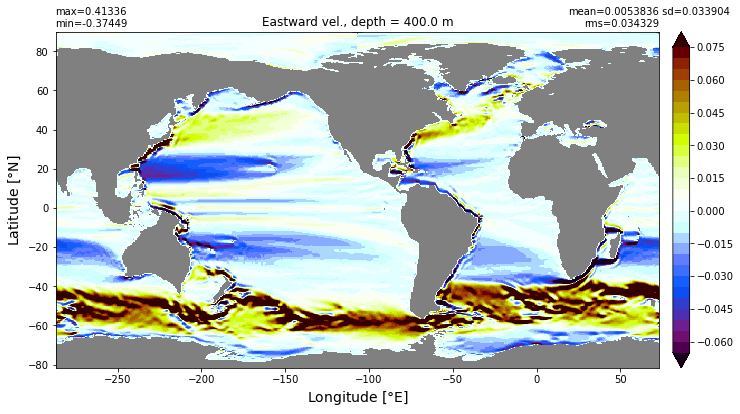

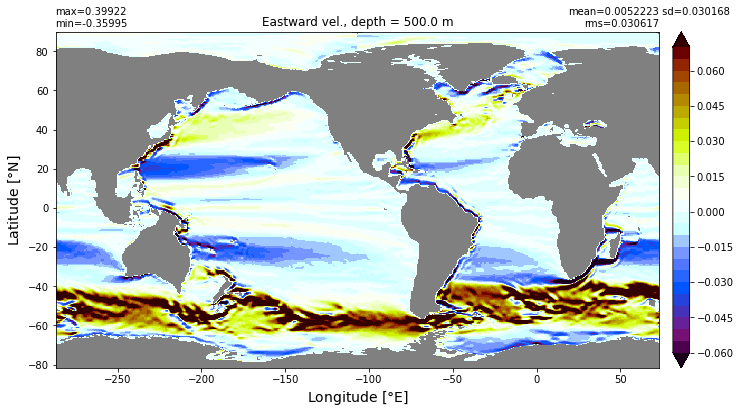

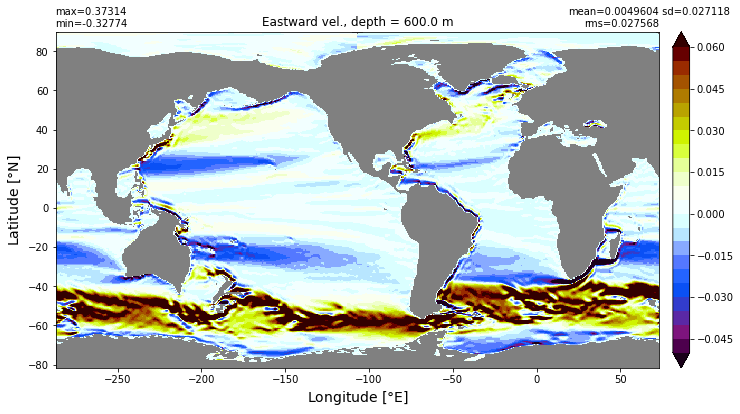

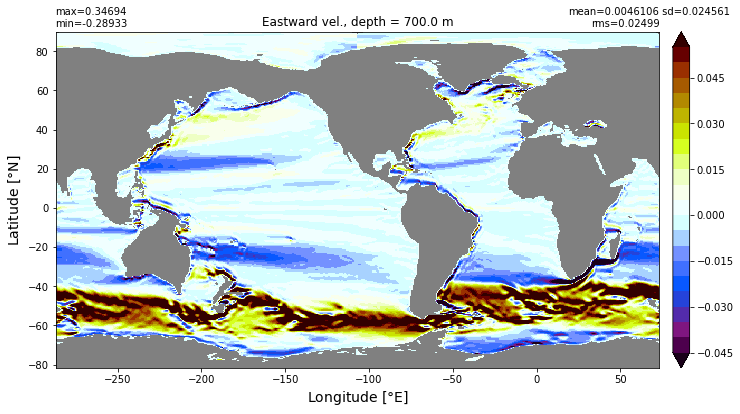

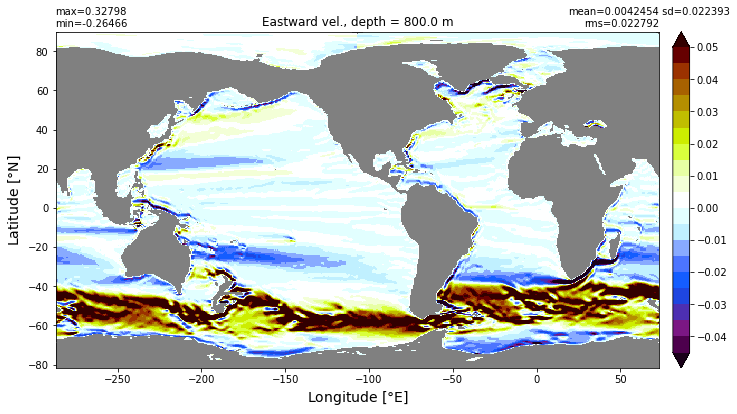

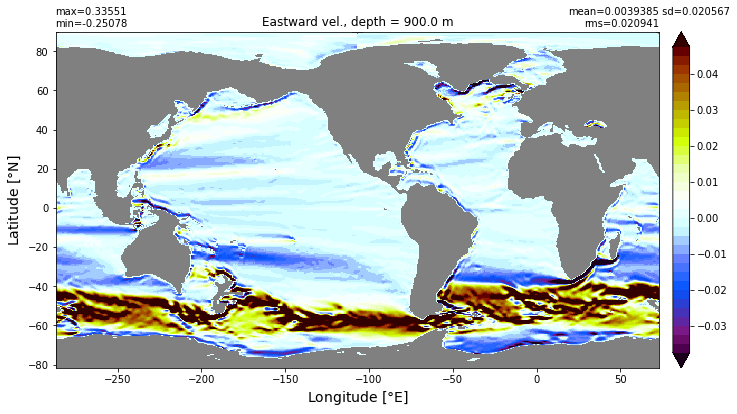

In [10]:
%matplotlib inline
# loop over depths 
km = uo.shape[0]
for k in range(km):
  # only shallower than 1000.0 m - this can be changed
  if ds_ann['z_l'][k].values < 1000.0:
    xyplot(uo[k,:],grd.geolon_u, grd.geolat_u, area=grd.areacello_cu,
          title = 'Eastward vel., depth = {} m'.format(str(ds_ann['z_l'][k].values)),
          extend='both',show= True)

### Meridional velocity

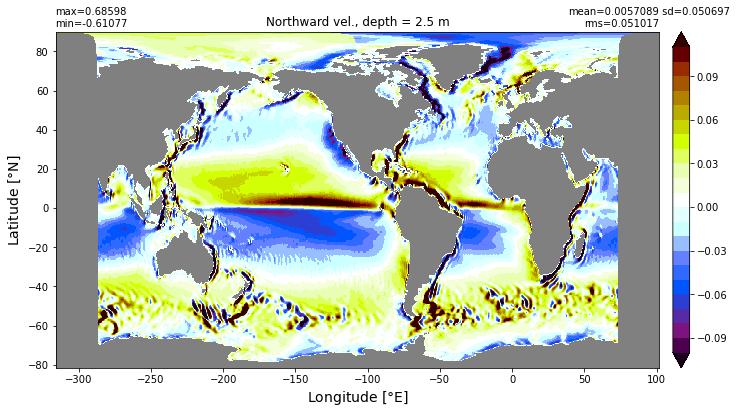

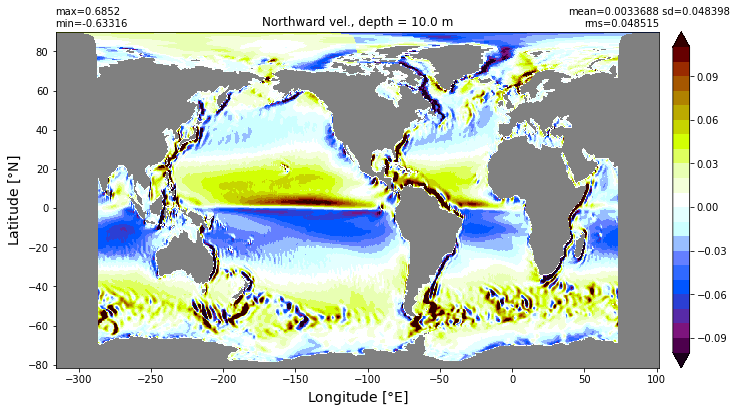

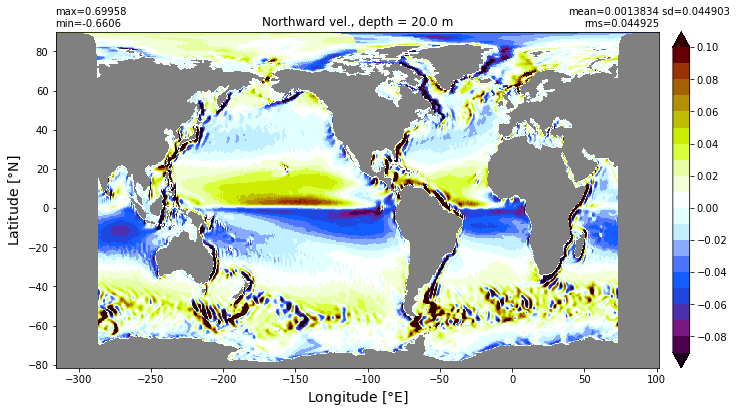

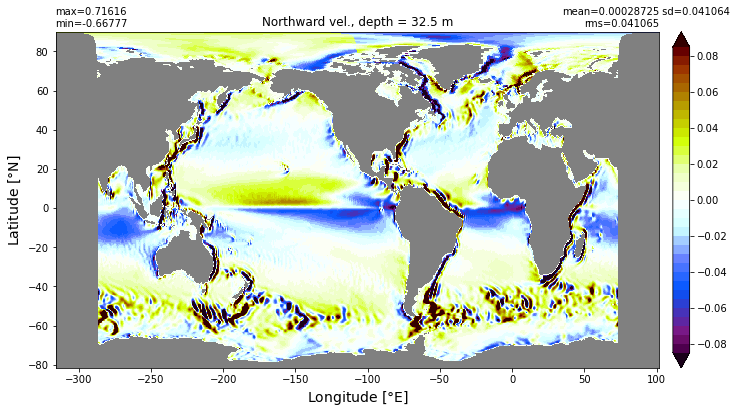

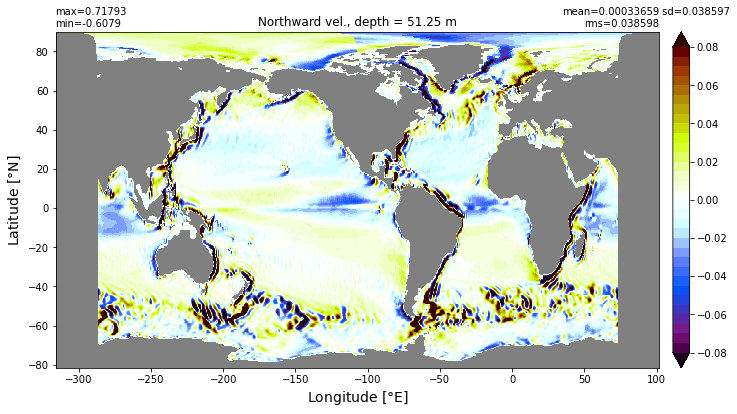

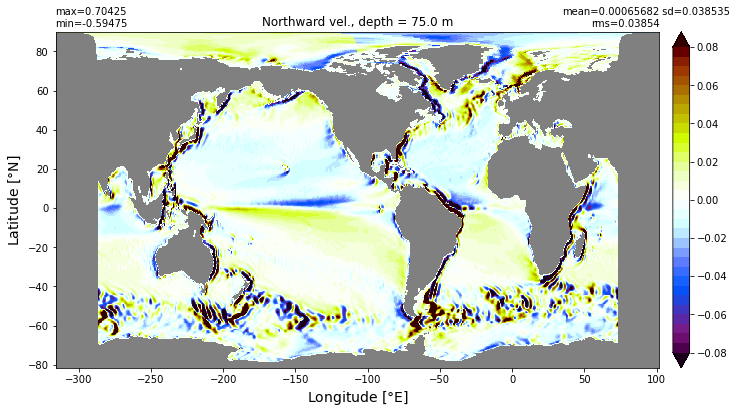

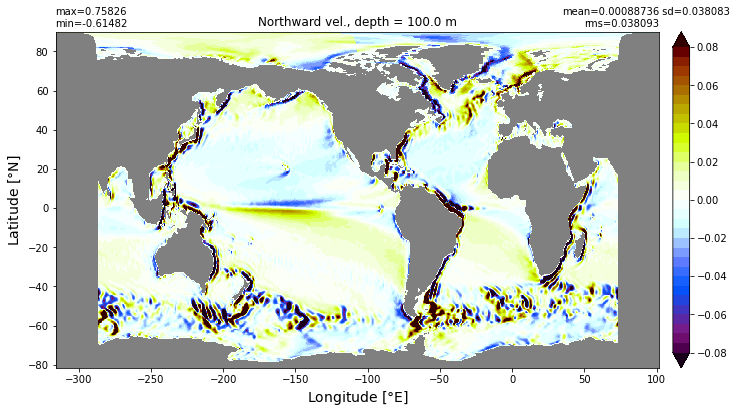

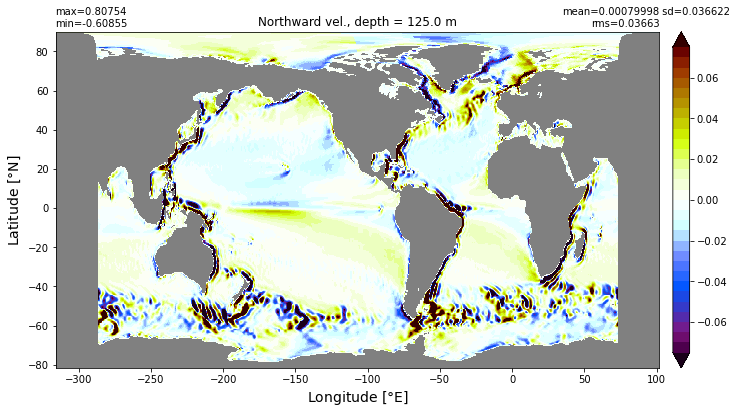

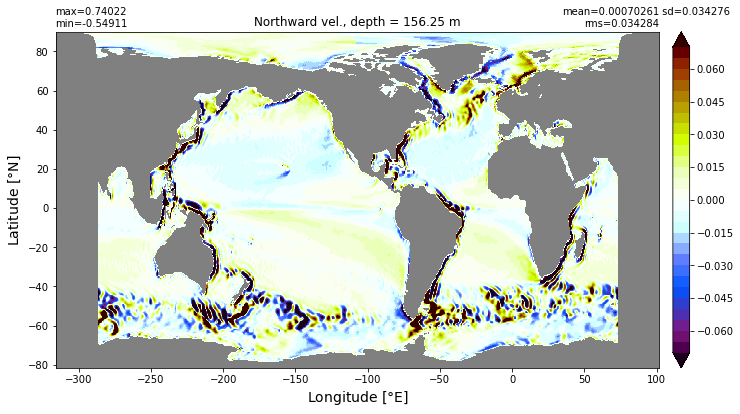

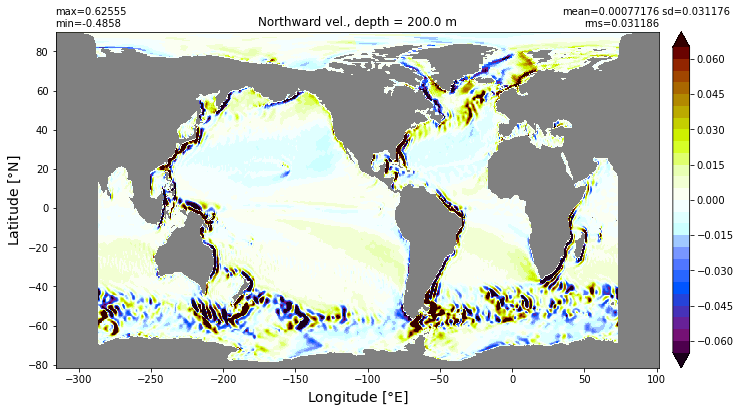

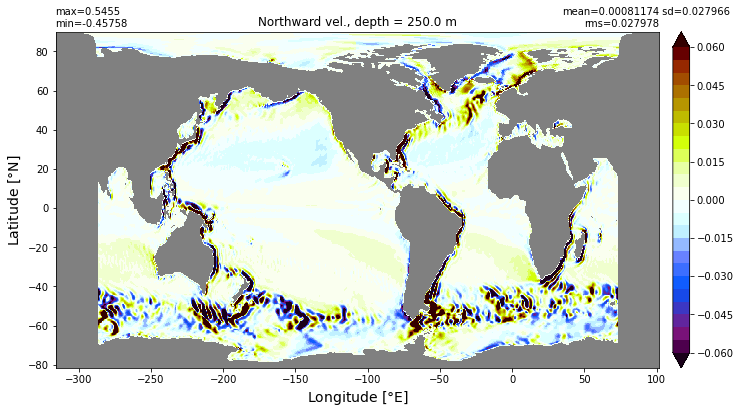

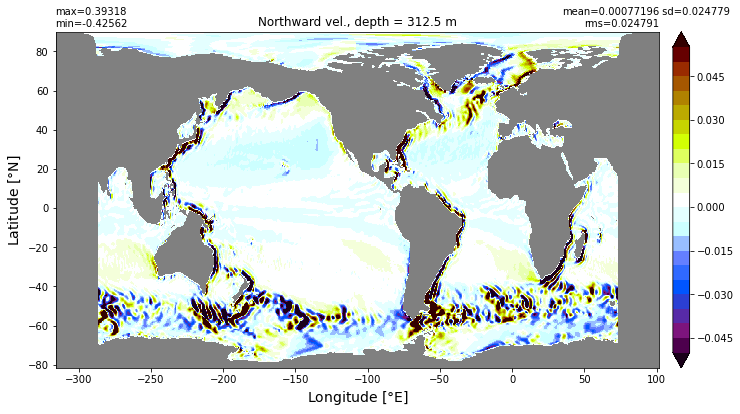

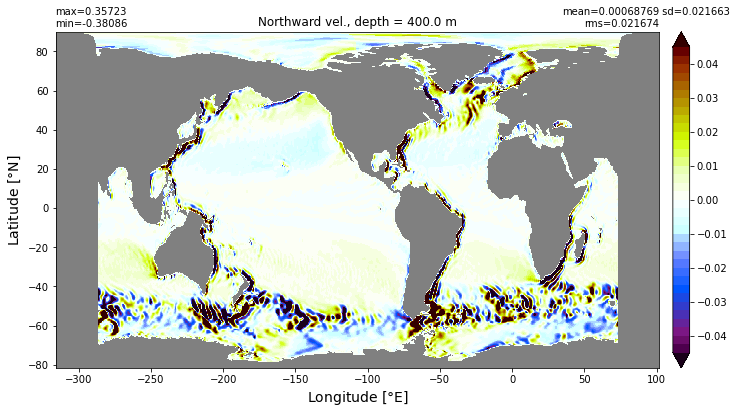

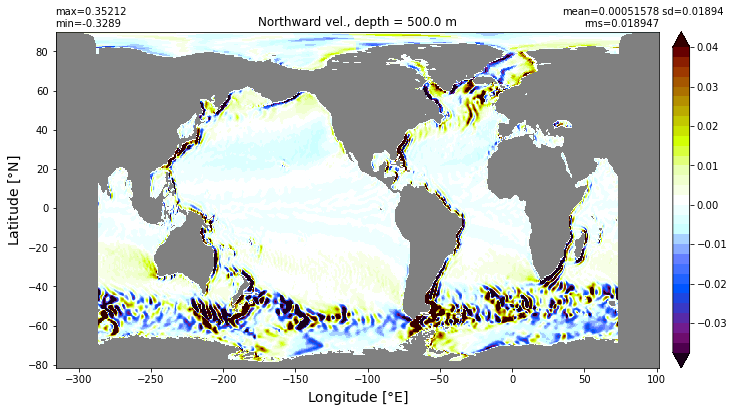

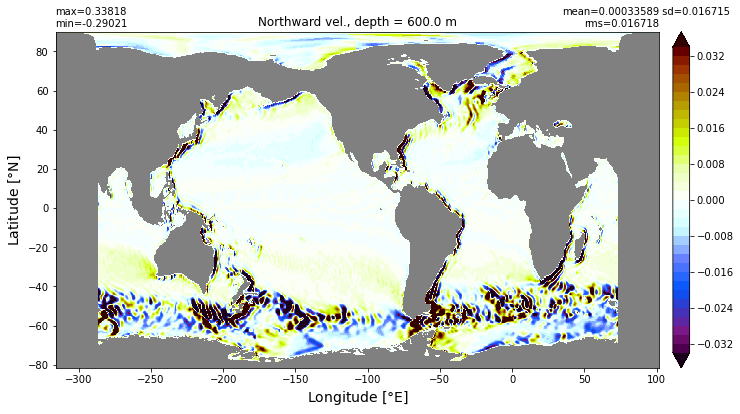

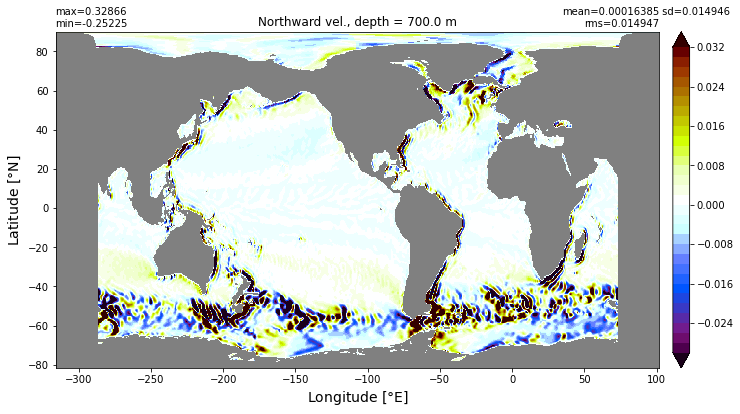

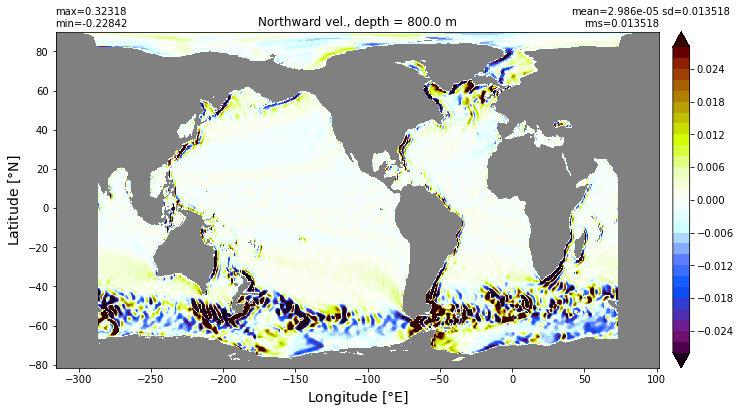

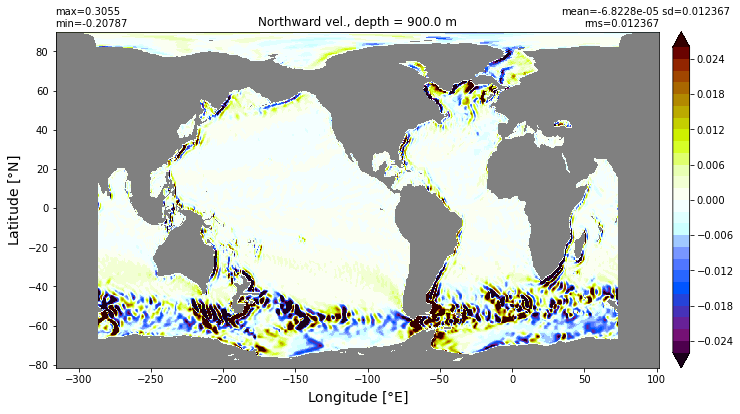

In [11]:
# loop over depths 
km = vo.shape[0]
for k in range(km):
  # only shallower than 1000.0 m - this can be changed
  if ds_ann['z_l'][k].values < 1000.0:
    xyplot(vo[k,:],grd.geolon_v, grd.geolat_v, area=grd.areacello_cv,
          title = 'Northward vel., depth = {} m'.format(str(ds_ann['z_l'][k].values)),
          extend='both',show= True)